In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers datasets accelerate scikit-learn seaborn

In [3]:
import pandas as pd
import numpy as np
import re

from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print(dataset)

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [5]:
label_names = dataset["train"].features["label"].names

print("Label names:", label_names)

Label names: ['negative', 'neutral', 'positive']


In [6]:
def clean_text(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Normalize user mentions
    text = re.sub(r"@\w+", "@user", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

print("Text cleaning function ready!")

Text cleaning function ready!


In [7]:
def preprocess_dataset(example):
    example["text"] = clean_text(example["text"])
    return example

dataset = dataset.map(preprocess_dataset)

print(dataset)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print("BERT tokenizer loaded successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT tokenizer loaded successfully!


In [9]:
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_data,
    batched=True
)

print(tokenized_dataset)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [10]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

print(tokenized_dataset["train"].column_names)

['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [11]:
from transformers import AutoModelForSequenceClassification

num_labels = 3

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print("BERT model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully!


In [12]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [13]:
import os

save_path = "/content/drive/MyDrive/BERT_Sentiment_Analysis/best_model"

os.makedirs(save_path, exist_ok=True)

print("Model save folder ready!")
print(save_path)

Model save folder ready!
/content/drive/MyDrive/BERT_Sentiment_Analysis/best_model


In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation metrics ready!")

Evaluation metrics ready!


In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_sentiment_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

print("Final training configuration ready!")

Final training configuration ready!


In [16]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [17]:
train_result = trainer.train()

print("Final BERT training completed successfully!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.608639,0.605707,0.734500,0.745379,0.734500,0.735364
2,0.514285,0.627653,0.747500,0.745824,0.747500,0.745279
3,0.413814,0.667960,0.749000,0.748809,0.749000,0.748836


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Final BERT training completed successfully!


In [18]:
# Save the best model selected by validation F1
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("BEST MODEL SAVED SUCCESSFULLY!")
print("Saved at:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BEST MODEL SAVED SUCCESSFULLY!
Saved at: /content/drive/MyDrive/BERT_Sentiment_Analysis/best_model


In [19]:
import os

print("Saved model files:")

for file in os.listdir(save_path):
    print("-", file)

Saved model files:
- config.json
- model.safetensors
- tokenizer_config.json
- tokenizer.json
- training_args.bin


In [20]:
test_results = trainer.evaluate(
    tokenized_dataset["test"]
)

print("FINAL TEST RESULTS")
print("------------------")

for key, value in test_results.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.413814,0.748851,3,0.693992,0.698174,0.693992,0.694179


FINAL TEST RESULTS
------------------
eval_loss: 0.7489
eval_accuracy: 0.6940
eval_precision: 0.6982
eval_recall: 0.6940
eval_f1: 0.6942


In [21]:
from sklearn.metrics import confusion_matrix

# Generate predictions on the test set
predictions_output = trainer.predict(
    tokenized_dataset["test"]
)

predicted_labels = np.argmax(
    predictions_output.predictions,
    axis=1
)

actual_labels = predictions_output.label_ids

# Create confusion matrix
final_cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[2864  962  146]
 [1089 3890  958]
 [  43  561 1771]]


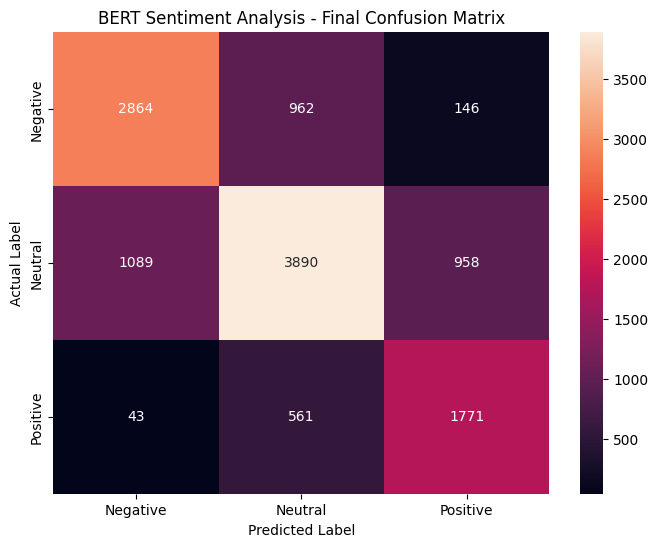

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("BERT Sentiment Analysis - Final Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [23]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class = torch.argmax(outputs.logits, dim=1).item()

    return id2label[predicted_class]


sample_tweets = [
    "I absolutely love this movie!",
    "The movie was okay, nothing special.",
    "This is the worst experience ever."
]

for tweet in sample_tweets:
    print("Tweet:", tweet)
    print("Prediction:", predict_sentiment(tweet))
    print("-" * 50)

Tweet: I absolutely love this movie!
Prediction: Positive
--------------------------------------------------
Tweet: The movie was okay, nothing special.
Prediction: Positive
--------------------------------------------------
Tweet: This is the worst experience ever.
Prediction: Negative
--------------------------------------------------


In [24]:
import torch

def predict_with_probability(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_class = torch.argmax(probabilities).item()

    print("Tweet:", text)
    print("Prediction:", id2label[predicted_class])
    print(f"Negative: {probabilities[0].item() * 100:.2f}%")
    print(f"Neutral : {probabilities[1].item() * 100:.2f}%")
    print(f"Positive: {probabilities[2].item() * 100:.2f}%")
    print("-" * 50)


predict_with_probability("I absolutely love this movie!")

Tweet: I absolutely love this movie!
Prediction: Positive
Negative: 0.62%
Neutral : 0.38%
Positive: 98.99%
--------------------------------------------------


In [25]:
samples = [
    "I absolutely love this movie!",
    "The movie was okay, nothing special.",
    "This is the worst experience ever."
]

for tweet in samples:
    predict_with_probability(tweet)

Tweet: I absolutely love this movie!
Prediction: Positive
Negative: 0.62%
Neutral : 0.38%
Positive: 98.99%
--------------------------------------------------
Tweet: The movie was okay, nothing special.
Prediction: Positive
Negative: 0.61%
Neutral : 5.76%
Positive: 93.63%
--------------------------------------------------
Tweet: This is the worst experience ever.
Prediction: Negative
Negative: 98.10%
Neutral : 1.46%
Positive: 0.44%
--------------------------------------------------
